### Basic Anomaly Detection of Financial Time Series Data using an Autoencoder
- Implementing an anomaly detection solution for stock prices involves training a PyTorch Autoencoder on "normal" historical data and using the reconstruction error to identify outliers.
- Dataset: The World Health Organisation declared COVID-19 a pandemic on 11 March 2020. For this analysis, we will use a tech stock (e.g., Apple - AAPL) and define the 3-year windows:
  - Pre-Covid (Training): March 2017 – March 2020.
  - Post-Covid (Testing): March 2020 – March 2023.
- Implementation Steps:
  1. Data Acquisition: Use the yfinance library to fetch daily historical data.
  2. Preprocessing: Scale the data (0 to 1) and create sliding window sequences for the model.
  3. Model Architecture: Define an Autoencoder class that compresses the input into a lower-dimensional latent space and reconstructs it.
  4. Anomaly Detection: Calculate the Mean Squared Error (MSE) between input and reconstruction. If the error exceeds a defined threshold, it is flagged as an anomaly.
  

### Imports

In [1]:
import torch
import torch.nn as nn
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from dataclasses import dataclass

### Define Configurations

In [ ]:
TOP_10_TECH_TICKERS = ["NVDA","AAPL","GOOGL", "MSFT", "AMZN", "TSM", "AVGO", "META", "TSLA", "ASML"]

@dataclass
class Config:
    ticker: str = 'UAL'
    start_date: str = '2015-03-11'
    end_date: str = '2025-03-11'
    covidemic_start_date: str = '2020-03-11'
    sequence_length: int = 30
    hidden_dim_1: int = 8
    hidden_dim_2: int = 6
    latent_dim: int = 4
    batch_size: int = 64
    num_epochs: int = 50
    learning_rate: float = 0.001
    
config = Config()

### Data processing:
- Get the data
- Scale the data
- Create data moving window


In [3]:
def load_data(ticker: str, start_date: str, end_date: str) -> np.ndarray:
    """
    Load historical stock price data for a given ticker and date range.
    :param ticker: Stock ticker symbol (e.g., 'AAPL' for Apple Inc.)
    :param start_date: Start date for data in 'YYYY-MM-DD' format   
    :param end_date: End date for data in 'YYYY-MM-DD' format
    :return: Numpy array of closing prices   
    """
    data_df = yf.download(ticker, start=start_date, end=end_date)
    return data_df['Close'].values.reshape(-1, 1), data_df

def split_train_test(data_df: pd.DataFrame, split_date: str):
    """
    Split the data into training and testing sets based on a specified date.
    :param data_df: DataFrame containing the stock price data
    :param split_date: Date to split the data into training and testing sets
    :return: Tuple of (training data, testing data)
    """
    split_idx = data_df.index.get_loc(pd.Timestamp(split_date))
    prices = data_df['Close'].values.reshape(-1, 1)
    train_data = prices[:split_idx]
    test_data = prices[split_idx:]
    return train_data, test_data

def scale_data(train_data: np.ndarray, test_data: np.ndarray):
    """
    Scale training and testing data using MinMaxScaler fitted on training data.
    :param train_data: Training data array
    :param test_data: Testing data array
    :return: Tuple of (scaled training data, scaled testing data, fitted scaler)
    """
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)
    return train_scaled, test_scaled, scaler

def create_sequences(data, seq_len=config.sequence_length) -> torch.Tensor:
    """Create sequences of data for training the model.
    :param data: Numpy array of scaled data
    :param seq_len: Length of each sequence
    :return: Torch tensor of sequences
    """
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return torch.tensor(np.array(sequences), dtype=torch.float32)


def preprocess_data(data: np.ndarray, sequence_length: int) -> (torch.Tensor, MinMaxScaler):
    """
    Preprocess the data by normalizing and creating sequences.
    :param data: Numpy array of closing prices
    :param sequence_length: Length of each input sequence for the model
    :return: Tuple of (input sequences as torch.Tensor, fitted MinMaxScaler)
    """
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    
    sequences = []
    for i in range(len(scaled_data) - sequence_length):
        sequences.append(scaled_data[i:i+sequence_length])
    
    return torch.tensor(sequences, dtype=torch.float32), scaler

In [4]:
data, data_df = load_data(config.ticker, config.start_date, config.end_date)
train_data, test_data = split_train_test(data_df, config.covidemic_start_date)
train_scaled, test_scaled, scaler = scale_data(train_data, test_data) 
X_train = create_sequences(train_scaled, config.sequence_length)
X_test = create_sequences(test_scaled, config.sequence_length)

data_df.head()

C:\Users\adeid\AppData\Local\Temp\ipykernel_23956\856029406.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CCL,CCL,CCL,CCL,CCL
Date,,,,,
2015-03-11,37.449852,37.706123,37.424226,37.612156,2500900
2015-03-12,38.688503,38.697044,37.962398,38.073450,4433100
2015-03-13,38.722664,38.782460,38.218663,38.346797,3774400
2015-03-16,39.551277,39.662329,38.910598,38.919142,3416800
2015-03-17,39.013107,39.201041,38.893514,39.064363,2506400


### Define Autoencoder
- An autoencoder is composed of an encoder / decoder blocks and a middle latent ("bottleneck") dimension layer
- Due to the time-series nature of our data set the autoencoder encoder/decoder blocks  will be consist of LSTM layers

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, config: Config):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(config.sequence_length, config.hidden_dim_1),
            nn.ReLU(),
            nn.Linear(config.hidden_dim_1, config.latent_dim)  # Latent space
        )
        self.decoder = nn.Sequential(
            nn.Linear(config.latent_dim, config.hidden_dim_1),
            nn.ReLU(),
            nn.Linear(config.hidden_dim_1, config.sequence_length)
        )

    def forward(self, x):
        x = x.squeeze(-1) # Flatten for Linear layers
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.unsqueeze(-1)


### Specify the Anomaly Detector

In [6]:
class AnomalyDetector:
    """
    Anomaly Detector based on a LSTM-Autoencoder model
    """
    def __init__(self, config: Config):
        """
        Initialize the AnomalyDetector with the given configuration.
        :param config: Config object containing hyperparameters such as sequence length, hidden dimensions, latent dimension, batch size, number of epochs, and learning rate.
        """
        self.config = config
        self.model = Autoencoder(self.config)
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config.learning_rate)
        self.anomalies = None

    def training_loop(self):
        for epoch in range(config.num_epochs):
            self.model.train()
            self.optimizer.zero_grad()
            output = self.model(X_train)
            loss = self.criterion(output, X_train)
            loss.backward()
            self.optimizer.step()
    
    def predict_anomalies(self):
        self.model.eval()
        with torch.no_grad():
            # Calculate reconstruction error
            reconstructed = self.model(X_test)
            test_loss = torch.mean((X_test - reconstructed)**2, dim=(1, 2)).numpy()

        # Set threshold (e.g., 95th percentile of training loss)
        train_recon = self.model(X_train)
        train_loss = torch.mean((X_train - train_recon)**2, dim=(1, 2)).detach().numpy()
        threshold = np.percentile(train_loss, 95)

        # Identify anomalies
        self.anomalies = test_loss > threshold
        return self.anomalies

    def plot_results(self, config: Config):
        plt.figure(figsize=(12, 6))
        # plt.plot(test_data[config.sequence_length:], label='Actual Price', alpha=0.7)
        plt.plot(data_df["Close"], label='Actual Price', alpha=0.7)
        anomaly_indices = np.where(self.anomalies)[0]
        plt.scatter(anomaly_indices, test_data[config.sequence_length:][self.anomalies], color='red', label='Anomaly')
        plt.title(f"Anomaly Detection for {config.ticker} (Post-Covid Period)")
        plt.legend()
        plt.show()




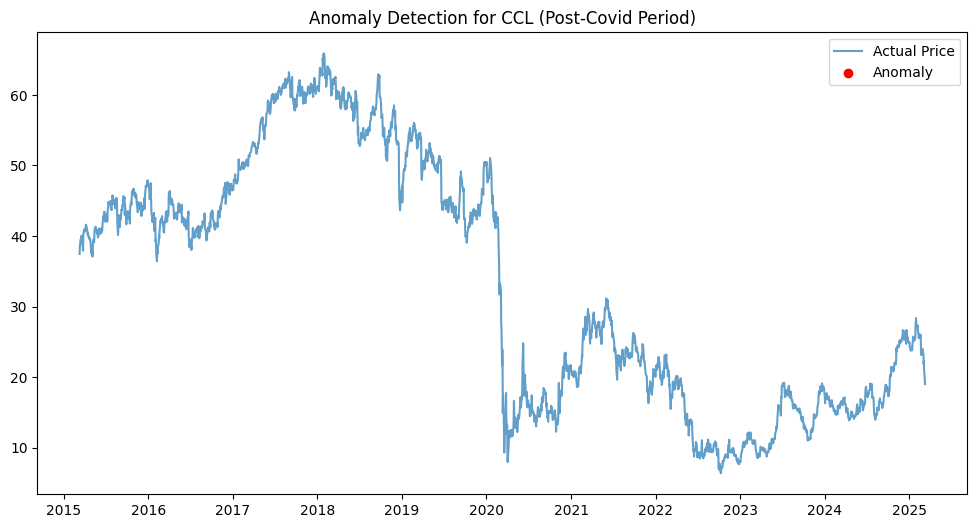

In [7]:
detector = AnomalyDetector(config)
detector.training_loop()
anomalies = detector.predict_anomalies()
detector.plot_results(config)


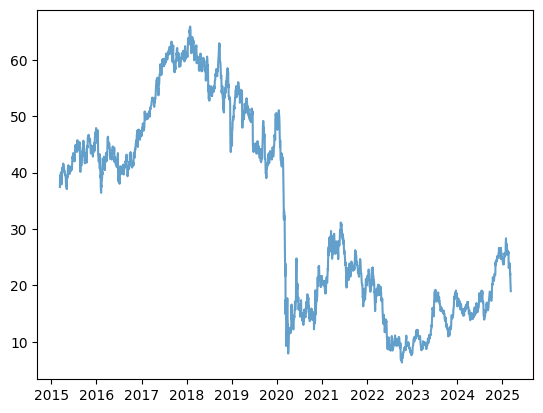

In [8]:
plt.plot(data_df["Close"], label='Actual Price', alpha=0.7)